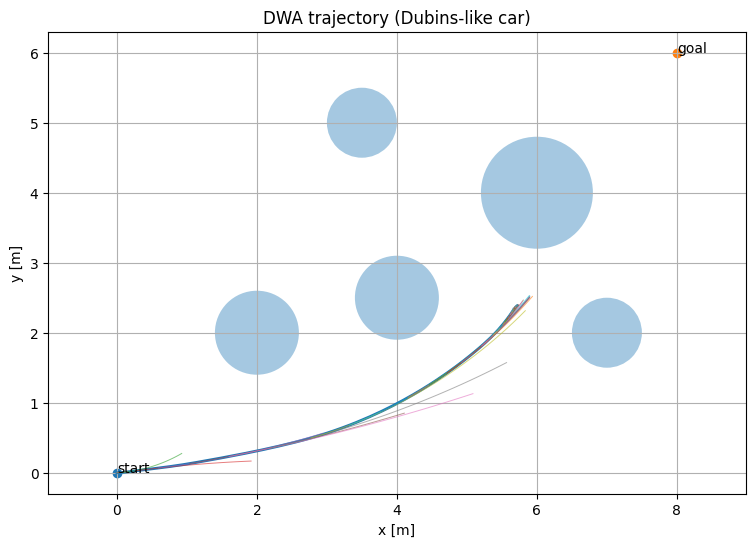

In [2]:
# DWA implementation for a Dubins-like car (x_dot = v cosθ, y_dot = v sinθ, θ_dot = ω)
# This code simulates the Dynamic Window Approach from scratch and plots the result.
# It is self-contained. You can change goal, obstacles, and parameters.
import math
import random
import numpy as np
import matplotlib.pyplot as plt

# --- Robot / DWA parameters ---
max_speed = 1.2        # [m/s]
min_speed = 0.0        # [m/s]
max_yaw_rate = 1.0     # [rad/s]
max_accel = 0.5        # [m/s^2]
max_delta_yaw = 1.0    # [rad/s^2] - angular acceleration limit (for window)
dt = 0.1               # control time step (s)
predict_time = 3.0     # seconds to simulate each candidate
robot_radius = 0.3     # robot radius for collision checking (m)

# weights for objective
to_goal_cost_gain = 1.0
speed_cost_gain = 0.1
obstacle_cost_gain = 1.0

# sampling resolution in control space
v_samples = 7
w_samples = 15

# --- Environment ---
start = np.array([0.0, 0.0, 0.0])  # x, y, theta
goal = np.array([8.0, 6.0])        # x, y
# obstacle list: (x, y, radius)
obstacles = [
    (2.0, 2.0, 0.6),
    (4.0, 2.5, 0.6),
    (6.0, 4.0, 0.8),
    (3.5, 5.0, 0.5),
    (7.0, 2.0, 0.5),
]

# helper functions
def motion(state, control, dt):
    """
    Dubins-like kinematic update:
    state: [x,y,theta]
    control: [v, omega]
    """
    x, y, th = state
    v, w = control
    x += v * math.cos(th) * dt
    y += v * math.sin(th) * dt
    th += w * dt
    # normalize angle
    th = (th + math.pi) % (2 * math.pi) - math.pi
    return np.array([x, y, th])

def calc_dynamic_window(current_v, current_w):
    """
    Build the dynamic window (feasible velocity region) from limits and current speeds
    Returns [v_min, v_max, w_min, w_max]
    """
    # vehicle limits
    vs = [min_speed, max_speed, -max_yaw_rate, max_yaw_rate]

    # dynamic constraints from current state (acc limits)
    vd = [
        current_v - max_accel * dt,
        current_v + max_accel * dt,
        current_w - max_delta_yaw * dt,
        current_w + max_delta_yaw * dt
    ]

    # intersection
    dw = [max(vs[0], vd[0]), min(vs[1], vd[1]), max(vs[2], vd[2]), min(vs[3], vd[3])]
    return dw

def predict_trajectory(state, v, w):
    """
    Simulate forward for predict_time using constant control (v,w)
    Returns list of states along the trajectory (x,y,theta)
    """
    traj = [state.copy()]
    t = 0.0
    s = state.copy()
    while t <= predict_time:
        s = motion(s, (v, w), dt)
        traj.append(s.copy())
        t += dt
    return np.array(traj)

def calc_obstacle_cost(traj, obstacles):
    """
    Obstacle cost: based on minimum distance to any obstacle along trajectory.
    If collision (distance <= robot_radius + obs_radius) -> large cost (inf)
    """
    min_r = float("inf")
    for (ox, oy, orad) in obstacles:
        dists = np.hypot(traj[:,0] - ox, traj[:,1] - oy) - orad
        min_d = dists.min()
        if min_d <= robot_radius * 0.5:
            # collision or very close - immediate reject by returning inf cost
            return float("inf")
        if min_d < min_r:
            min_r = min_d
    # cost inversely proportional to clearance; larger clearance -> smaller cost
    # add small epsilon to avoid division by zero
    return 1.0 / (min_r + 1e-6)

def calc_to_goal_cost(traj, goal):
    """
    Cost to goal - measured using the final point of the trajectory
    Lower distance = lower cost
    """
    dx = goal[0] - traj[-1,0]
    dy = goal[1] - traj[-1,1]
    dist = math.hypot(dx, dy)
    return dist

def normalize_costs(costs):
    """
    Normalize array of costs to [0,1]
    """
    costs = np.array(costs, dtype=float)
    if costs.max() - costs.min() < 1e-6:
        return np.zeros_like(costs)
    return (costs - costs.min()) / (costs.max() - costs.min())

# --- DWA main loop ---
def dwa_control(state, current_v, current_w, goal, obstacles):
    dw = calc_dynamic_window(current_v, current_w)
    v_min, v_max, w_min, w_max = dw

    # sample velocities
    v_samples_list = np.linspace(v_min, v_max, v_samples)
    w_samples_list = np.linspace(w_min, w_max, w_samples)

    trajectories = []
    costs = []

    for v in v_samples_list:
        for w in w_samples_list:
            traj = predict_trajectory(state, v, w)
            ob_cost = calc_obstacle_cost(traj, obstacles)
            if ob_cost == float("inf"):
                # too close or collision -> skip but record big cost
                total_cost = float("inf")
            else:
                to_goal = calc_to_goal_cost(traj, goal)
                # We want to minimize to_goal and obstacle cost, and prefer higher speed (so negative speed cost)
                total_cost = (to_goal_cost_gain * to_goal) + \
                             (obstacle_cost_gain * ob_cost) - \
                             (speed_cost_gain * v)
            trajectories.append((v, w, traj))
            costs.append(total_cost)

    # pick best (lowest) total cost
    costs = np.array(costs)
    if np.isinf(costs).all():
        # all trajectories are invalid -> stop or pick the best clearance (max min distance)
        # Here we fallback to staying in place (zero velocities)
        return 0.0, 0.0, []

    best_idx = np.nanargmin(costs)
    best_v, best_w, best_traj = trajectories[best_idx]
    return best_v, best_w, best_traj

# simulation
state = start.copy()
current_v = 0.0
current_w = 0.0

trajectory = [state.copy()]
predicted_sets = []  # store predicted trajectories at each step for plotting
time = 0.0
max_sim_time = 120.0  # safety
goal_tolerance = 0.25

while time < max_sim_time:
    # check reached goal
    if math.hypot(state[0]-goal[0], state[1]-goal[1]) <= goal_tolerance:
        print("Goal reached at time", round(time,2))
        break

    # compute control using DWA
    best_v, best_w, best_traj = dwa_control(state, current_v, current_w, goal, obstacles)

    # apply acceleration limits to smoothly reach best_v and best_w from current
    # clip acceleration for v
    if best_v > current_v:
        current_v = min(best_v, current_v + max_accel * dt)
    else:
        current_v = max(best_v, current_v - max_accel * dt)

    # clip yaw acceleration
    if best_w > current_w:
        current_w = min(best_w, current_w + max_delta_yaw * dt)
    else:
        current_w = max(best_w, current_w - max_delta_yaw * dt)

    # move robot for one timestep using current control
    state = motion(state, (current_v, current_w), dt)
    trajectory.append(state.copy())

    # store predicted trajectories to plot later (subsample to avoid huge memory)
    if best_traj is not None and len(predicted_sets) < 200:
        predicted_sets.append(best_traj)

    time += dt

# convert to numpy for plotting
trajectory = np.array(trajectory)

# --- Plotting ---
plt.figure(figsize=(9,6))
# obstacles
for (ox, oy, orad) in obstacles:
    circle = plt.Circle((ox, oy), orad, fill=True, alpha=0.4)
    plt.gca().add_patch(circle)

# robot path
plt.plot(trajectory[:,0], trajectory[:,1], linewidth=2)
plt.scatter([start[0]], [start[1]])
plt.text(start[0], start[1], "start")
plt.scatter([goal[0]], [goal[1]])
plt.text(goal[0], goal[1], "goal")

# predicted trajectories (few) - plot with lower alpha
for traj in predicted_sets[::5]:
    plt.plot(traj[:,0], traj[:,1], linewidth=0.7, alpha=0.6)

plt.axis("equal")
plt.grid(True)
plt.title("DWA trajectory (Dubins-like car)")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.show()
